*© 2026 Paul Fergus*

# Lab 6 — Annotating images for object detection

**Module:** 7144COMP — Deep Learning Concepts and Techniques
**Week:** 6
**Estimated time:** 180 minutes

---

## Learning outcomes

By the end of this lab you should be able to:

1. Explain the difference between **image classification** (what's in this image?) and **object detection** (what's in this image, where, and how many of each?).
2. Read, write, and *validate* labels in the **YOLO text format**, including normalised centre-based bounding box coordinates.
3. Annotate a folder of images using the module's built-in bounding-box annotator and produce a clean YOLO-format label set.
4. Build a valid Ultralytics `data.yaml` specification linking your image folder, label folder, class list, and train/val/test split.
5. Visualise existing annotations by rendering bounding boxes back onto their source images — the critical 'closing-the-loop' step that catches off-by-one errors and class-mapping mistakes.
6. Apply common annotation hygiene rules — tight boxes, consistent class assignment, handling of edge cases like truncation, occlusion, and ambiguous identification.
7. Explain why real-world datasets usually arrive **pre-split**, and why reshuffling a published split yourself is usually the wrong instinct.

## Prerequisites

- **Labs 1–5** completed. The pipeline knowledge from Lab 5 will be directly extended here.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 7 — object detection.
- Lecture 6: *From classification to detection — bounding boxes, IoU, and the YOLO family of models*.

## A different kind of lab

Up to now every lab has been about *training a model*. This one is about **preparing the data a model will train on**. That sounds less glamorous than the modelling work, but in industry the ratio is typically 70/30 data work to modelling work, sometimes much higher. **The quality ceiling on any deep learning project is set by the quality of the labels.** A model trained on inconsistent or careless annotations will be inconsistent or careless. There is no clever architecture that fixes bad data.

Today we annotate. Next week we'll train an object detector on the dataset you produce here.

## The dataset — real photographs, not synthetic ones

This lab uses the **African Wildlife dataset**, published by Ultralytics: 1,504 real photographs across four classes — **buffalo, elephant, rhino, zebra** — already split into train/val/test by the dataset's authors. You'll meet the full dataset properly in Section 5. For now, a **curated subset of 24 images** lives in `data/images/` — these are the ones *you* will annotate by hand today, from scratch. They've been picked to span all four species and a realistic range of difficulty: single-animal shots, herd shots with a dozen animals in one frame, and a few genuinely small, distant subjects.

> **Licence note.** The African Wildlife dataset is distributed by Ultralytics under **AGPL-3.0**, the same licence you'll meet again with YOLO26 in Lab 7. Fine for academic use; see Lab 7's licence discussion if you ever consider shipping something built on it commercially.

## What you'll build

By the end of this session you will have:

- 24 real wildlife photographs, each annotated with bounding boxes for every animal visible from the four-class list: **buffalo, elephant, rhino, zebra**.
- A matching folder of YOLO-format `.txt` files, one per image.
- A `data.yaml` declaration file that the `ultralytics` training pipeline can ingest.
- A working understanding of the **full 1,504-image dataset** sitting in `data/full_dataset/`, which Lab 7 will train on.

## Useful references

- [Ultralytics African Wildlife dataset documentation](https://docs.ultralytics.com/datasets/detect/african-wildlife/)
- [Ultralytics dataset format documentation](https://docs.ultralytics.com/datasets/detect/)
- [Roboflow's guide to writing good bounding boxes](https://blog.roboflow.com/labeling/) — vendor blog but covers the hygiene rules well.

---

## 1. The YOLO text format, dissected

Every object detector needs to know *where* objects are, not just *what* they are. The YOLO family encodes a bounding box as four numbers, plus a class id, all on one line:

```
class_id  cx  cy  w  h
```

For example:

```
1 0.523000 0.487000 0.214000 0.299000
```

Reading this off:

| Field      | Meaning |
|------------|---------|
| `1`        | Class id (in our dataset: `0=buffalo, 1=elephant, 2=rhino, 3=zebra`) |
| `0.523000` | **`cx`** — x-coordinate of box centre, **normalised** (0 = left edge, 1 = right edge) |
| `0.487000` | **`cy`** — y-coordinate of box centre, **normalised** (0 = top, 1 = bottom) |
| `0.214000` | **`w`** — box width, **normalised** (fraction of image width) |
| `0.299000` | **`h`** — box height, **normalised** (fraction of image height) |

**Two things worth pausing on:**

1. The format uses the box **centre**, not the corner. Many other formats (Pascal VOC, COCO) use `xmin, ymin, xmax, ymax` corners. Mixing them up is a classic bug — see Exercise 2.
2. All four geometric fields are **normalised by image dimensions**. This means the same `.txt` file is valid whether the image is 800×600 or 4096×3072 — the label is intrinsically resolution-independent. This is why YOLO's format scales so well across heterogeneous datasets, and it's exactly why the images in this dataset can vary in size (they do) without causing you any problems.

**Per-image rule:** one `.txt` file per image, named with the same stem (e.g. `wildlife_03.jpg` → `wildlife_03.txt`). One row per object instance. If there are no objects in the image, the `.txt` file is empty (but should still exist).

## 2. The hands-on bit — open the annotator

The module's container ships with a built-in bounding-box annotator that writes YOLO-format files directly into the bind-mounted `data/labels/` folder. **Open it now in a new tab:**

> **▶ <http://localhost:8000/annotator>**

(Or click the *Open annotator* button on the launcher home page.)

### What you should see

Three panels: a list of all 24 images on the left, a canvas with the current image in the middle, and a class picker plus a live view of the YOLO label file on the right. The keyboard shortcuts at the bottom of the canvas — click-and-drag to draw, number keys to pick a class, arrow keys to move between images — are the fastest way to work.

**Zoom and pan.** Several of these photos contain animals that are small or distant relative to the frame — real wildlife photography, unlike a studio shot, rarely puts the subject front-and-centre at a convenient size. Use the **mouse wheel** to zoom in toward the cursor (up to 12×), and **Shift + click-drag** to pan around once you're zoomed in. The `+` / `-` / `0` keys also work for zoom in / out / fit-to-pane. **Crucially: the saved coordinates are unaffected by zoom level** — zoom is just a viewing aid, the YOLO `.txt` file always contains normalised `[0, 1]` values regardless of how you drew the boxes.

### Your task

**Annotate all 24 images.** For each one:

1. Look at the image. Identify every animal that's clearly visible.
2. Pick the right class (1–4 keys or the buttons).
3. Draw a tight box around the animal — including everything that's obviously part of it (tail, legs, ears, horns) — excluding background, *not* including parts of other animals.
4. If the animal is **partly cut off by the edge of the image**, still draw a box around the visible part. Truncation is normal in real photography and detectors handle it fine.
5. Some images are **herd shots** with many animals of the same species — draw one box per individual, even when this means a dozen boxes in one photo. This is tedious by design: real annotation work often is, and learning to stay consistent on box 12 the same way you were on box 1 is the actual skill.
6. If you're **unsure of the species**, skip it for now. Better an unlabelled example than a wrong one. (We return to this in Exercise 2.)

The annotator auto-saves on every change. There's no save button. As you draw, watch the *YOLO label file* panel on the right — you're literally writing the rows of the label file as you click and drag.

**Aim for tight boxes.** Loose boxes leak background pixels into the model's idea of what 'elephant' looks like, and the detector learns that 'elephant = lots of savanna with a smaller elephant-shape in it'. Tight is better.

**Come back here once you've labelled all 24 images.** The 'image list' panel on the left will show how many boxes each image has. Aim for 'all 24 labelled, with a total somewhere around 60 boxes across the set' — the herd shots pull that average up well above one box per image.

## 3. Inspect your work — load the labels back into Python

**Always validate your annotations visually.** Reading the raw `.txt` numbers tells you nothing about whether the boxes are sensible. Re-rendering them on top of the images closes the loop and catches:

- Off-by-one errors (e.g. confused row/column order)
- Class-id mistakes ("this is labelled `2 rhino` but actually it's a buffalo")
- Boxes that drifted from the object during a resize
- Truncation issues at image edges

We use the same `PIL` + `matplotlib` we've been using all module. No special libraries needed.

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"

# Read the class list — single source of truth.
with open(DATA_DIR / "classes.txt") as f:
    classes = [line.strip() for line in f if line.strip()]
print(f"Classes ({len(classes)}): {classes}")

# A per-class colour list for plotting — used consistently in every later lab too.
CLASS_COLOURS = {
    0: "#d6336c",   # buffalo
    1: "#f59f00",   # elephant
    2: "#2b8a3e",   # rhino
    3: "#1c7ed6",   # zebra
}

In [ ]:
def read_yolo_labels(label_path: Path) -> list[dict]:
    """Parse a YOLO .txt file. Returns a list of dicts with class_id, cx, cy, w, h."""
    if not label_path.is_file():
        return []
    boxes = []
    for line in label_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            print(f"  WARNING: malformed line in {label_path.name}: {line!r}")
            continue
        cls_id = int(parts[0])
        cx, cy, w, h = [float(x) for x in parts[1:]]
        boxes.append({"class_id": cls_id, "cx": cx, "cy": cy, "w": w, "h": h})
    return boxes


def draw_image_with_boxes(image_path: Path, boxes: list[dict], ax=None):
    """Render an image with overlaid bounding boxes on the given axis."""
    img = Image.open(image_path)
    W, H = img.size
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.axis("off")

    for b in boxes:
        # Convert centre-based normalised back to corner-based pixels.
        x = (b["cx"] - b["w"] / 2) * W
        y = (b["cy"] - b["h"] / 2) * H
        w = b["w"] * W
        h = b["h"] * H
        colour = CLASS_COLOURS.get(b["class_id"], "#888888")
        rect = patches.Rectangle((x, y), w, h, linewidth=2.5,
                                  edgecolor=colour, facecolor="none")
        ax.add_patch(rect)
        # Label background and text
        label = classes[b["class_id"]] if 0 <= b["class_id"] < len(classes) else f"cls{b['class_id']}"
        ax.text(x + 4, y - 6, label, color="white", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="square,pad=0.2", facecolor=colour, edgecolor="none"))
    return ax

Now look at every image with its current annotations. **If you haven't annotated yet, this will show blank images** — open the annotator and label them first.

In [ ]:
# Walk the images folder in sorted order so the output is deterministic.
image_files = sorted(IMAGES_DIR.glob("*.jpg"))

n_imgs = len(image_files)
n_cols = 4
n_rows = (n_imgs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows))
axes = axes.flatten()

total_boxes = 0
for ax, img_path in zip(axes, image_files):
    label_path = LABELS_DIR / (img_path.stem + ".txt")
    boxes = read_yolo_labels(label_path)
    total_boxes += len(boxes)
    draw_image_with_boxes(img_path, boxes, ax=ax)
    ax.set_title(f"{img_path.name}  ({len(boxes)} box{'es' if len(boxes) != 1 else ''})", fontsize=9)

for ax in axes[n_imgs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total: {total_boxes} boxes across {len(image_files)} images.")

**What to look for:**

- Every animal in every image has a box, including every individual in the herd shots.
- Every box is tight around its animal (no big gaps of background inside the box).
- Every box has the right class — colour-check it against the species you can see.
- Boxes that look 'shifted' from their animal usually mean an off-by-one bug in the annotator. We've tested ours but if you see something weird, report it.

**Re-open the annotator and fix anything you spot.** The label files update live; rerun the cell above to see the latest.

## 4. The `data.yaml` file

`ultralytics` (the library that ships YOLOv8/v11/26) needs one extra file: a `data.yaml` that tells it the dataset layout. It's a small file but it's the contract between your annotations and the trainer.

Required fields:

```yaml
path: /workspace/labs/lab06_image_annotation/data    # absolute path to the dataset root
train: images/train                                    # train images, relative to `path`
val:   images/val                                      # validation images, relative to `path`
test:  images/test                                     # test images (optional but recommended)

names:
  0: buffalo
  1: elephant
  2: rhino
  3: zebra
```

`ultralytics` looks for label files in the *parallel* folder `labels/<split>/` next to each `images/<split>/`. So our flat 24-image pool needs to be reorganised slightly to get there.

## 5. Train / val / test split for object detection

We split into 70% train / 15% val / 15% test, but for object detection this needs a slightly different mindset from classification.

**Important: avoid frame-level leakage.** If your images came from a video — say, three frames at 0.04s intervals showing the same elephant in nearly the same pose — random shuffling will put one frame in train and another in val, and the validation score will be massively optimistic. The model will essentially have seen the validation image during training.

Our 24 images are independent photographs, so this isn't a risk here. For *your own* dataset later, **split at the level of unique scenes**, not individual frames.

In [5]:
import shutil
import yaml
import random

RNG_SEED = 7144
SPLIT = (0.7, 0.15, 0.15)

# Find every image that has at least one annotation. Images without
# annotations are excluded from training — you wouldn't want to teach
# the model 'this image is correctly labelled as containing nothing'
# unless you really do want negative examples.
labelled = [p for p in sorted(IMAGES_DIR.glob("*.jpg"))
            if (LABELS_DIR / (p.stem + ".txt")).is_file()
            and read_yolo_labels(LABELS_DIR / (p.stem + ".txt"))]

print(f"Labelled images available: {len(labelled)} of {len(image_files)}")

if len(labelled) < len(image_files):
    print("You haven't annotated every image yet — go back to step 2.")
else:
    rng = random.Random(RNG_SEED)
    rng.shuffle(labelled)
    n = len(labelled)
    n_train = int(n * SPLIT[0])
    n_val = int(n * SPLIT[1])
    splits = {
        "train": labelled[:n_train],
        "val":   labelled[n_train:n_train + n_val],
        "test":  labelled[n_train + n_val:],
    }
    for split_name, files in splits.items():
        print(f"  {split_name:<5}: {len(files)} images")

Labelled images available: 40 of 40
  train: 28 images
  val  : 6 images
  test : 6 images


In [6]:
# Build the directory layout that ultralytics expects.
# We create images/{train,val,test} and labels/{train,val,test} side-by-side.

OUT_ROOT = DATA_DIR  # we write the split structure right next to the flat one

for split in ("train", "val", "test"):
    (OUT_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# We *copy* (not move) so the flat data/images/ stays intact for re-annotation.
for split_name, files in splits.items():
    for fp in files:
        shutil.copy2(fp, OUT_ROOT / "images" / split_name / fp.name)
        label_src = LABELS_DIR / (fp.stem + ".txt")
        shutil.copy2(label_src, OUT_ROOT / "labels" / split_name / (fp.stem + ".txt"))
    print(f"  {split_name}: {len(files)} files copied to images/{split_name}/ and labels/{split_name}/")

# Write the data.yaml. We use a relative `path` so the file works regardless
# of where the container is mounted on the host.
data_yaml = {
    "path": str((OUT_ROOT).resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(classes)},
}

yaml_path = OUT_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f"\nWrote {yaml_path}")
print("\nContents:")
print(yaml_path.read_text())

  train: 28 files copied to images/train/ and labels/train/
  val: 6 files copied to images/val/ and labels/val/
  test: 6 files copied to images/test/ and labels/test/

Wrote data/data.yaml

Contents:
path: /workspace/labs/lab06_image_annotation/data
train: images/train
val: images/val
test: images/test
names:
  0: buffalo
  1: elephant
  2: rhino
  3: zebra



**Sanity check.** When we get to the YOLO training lab, the trainer will fail with a useful error if anything is wrong with this setup. But let's catch problems now while we still know what we did. Three checks:

1. Every image in `images/<split>/` has a corresponding `labels/<split>/<stem>.txt`.
2. Every class id in every label file is within range `0..len(classes)-1`.
3. Every box's coordinates are within `[0, 1]`.

In [22]:
issues = []

for split in ("train", "val", "test"):
    img_dir = OUT_ROOT / "images" / split
    lbl_dir = OUT_ROOT / "labels" / split
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.is_file():
            issues.append(f"{split}: no label file for {img_path.name}")
            continue
        for i, line in enumerate(lbl_path.read_text().splitlines(), start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                issues.append(f"{split}/{lbl_path.name} line {i}: not 5 fields")
                continue
            try:
                cls_id = int(parts[0])
                cx, cy, w, h = [float(x) for x in parts[1:]]
            except ValueError:
                issues.append(f"{split}/{lbl_path.name} line {i}: parse error")
                continue
            if not (0 <= cls_id < len(classes)):
                issues.append(f"{split}/{lbl_path.name} line {i}: class_id {cls_id} out of range")
            for fname, v in [("cx", cx), ("cy", cy), ("w", w), ("h", h)]:
                if not (0 <= v <= 1):
                    issues.append(f"{split}/{lbl_path.name} line {i}: {fname}={v} outside [0,1]")

if issues:
    print(f"{len(issues)} issue(s) found:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("All checks passed. Your dataset is ready to train on.")

All checks passed. Your dataset is ready to train on.


---

## 6. The full dataset — inheriting a pre-split, professional pool

The 24 images you just annotated are enough to *learn the mechanics* of annotation and to see your own boxes end-to-end through a `data.yaml`. They are **not** enough to train a genuinely useful detector — Lab 7 will make that limitation very visible.

That's not a flaw in the exercise; it's the normal shape of a real project. You rarely start from zero. Here, you've inherited something far more useful: the **complete African Wildlife dataset**, sitting in `data/full_dataset/` — **1,504 real photographs**, already annotated, already split into train/val/test by the people who published it.

```
data/full_dataset/
├── images/{train,val,test}/     ← 1,052 / 225 / 227 real photographs
├── labels/{train,val,test}/     ← matching YOLO-format annotations
├── data.yaml                    ← ready to hand to ultralytics as-is
└── LICENSE.txt                  ← AGPL-3.0, from Ultralytics
```

**Why we don't reshuffle it.** You might be tempted to merge everything into one pool and re-split it yourself, the way Section 5 just did for your 24 images. Don't. Three reasons:

1. **Reproducibility.** Anyone else using this dataset — including whoever published benchmark numbers against it — used *this* split. If you reshuffle, your results are no longer comparable to anyone else's.
2. **Hidden structure.** A published split sometimes encodes something you can't see from the filenames alone — e.g. images from the same photo session kept together to avoid the frame-leakage problem from Section 5. Reshuffling can silently reintroduce exactly the leakage the original authors avoided.
3. **No benefit.** Random re-splitting only helps if you suspect the existing split is broken. Absent evidence of that, it's pure risk for zero upside.

**The rule of thumb:** build your own split only when you built the dataset. Inherit the split when you inherited the dataset.

In [23]:
import yaml as _yaml

FULL_ROOT = DATA_DIR / "full_dataset"
with open(FULL_ROOT / "data.yaml") as f:
    full_cfg = _yaml.safe_load(f)

print("Full dataset classes:", full_cfg["names"])
print()
for split in ("train", "val", "test"):
    img_dir = FULL_ROOT / full_cfg[split]
    n = len(list(img_dir.glob("*.jpg")))
    lbl_dir = FULL_ROOT / full_cfg[split].replace("images", "labels")
    n_boxes = sum(len(read_yolo_labels(p)) for p in lbl_dir.glob("*.txt"))
    print(f"  {split:<5}: {n:>5} images, {n_boxes:>6} boxes total ({n_boxes/max(n,1):.1f} per image)")

Full dataset classes: {0: 'buffalo', 1: 'elephant', 2: 'rhino', 3: 'zebra'}

  train:  1052 images,   1931 boxes total (1.8 per image)
  val  :   225 images,    379 boxes total (1.7 per image)
  test :   227 images,    375 boxes total (1.7 per image)


Render a handful of images from the full training pool — this is what Lab 7 will actually learn from.

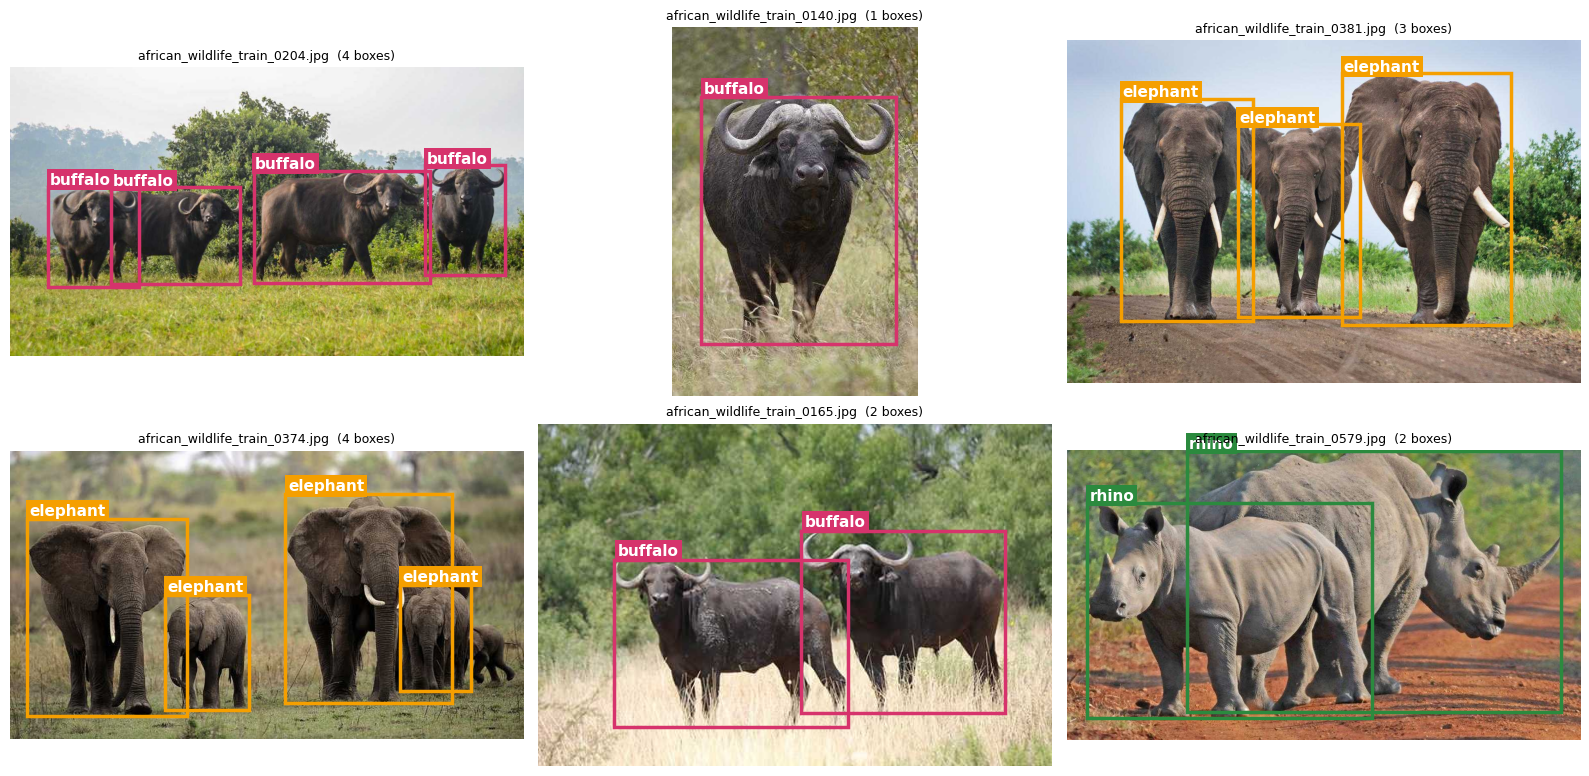

In [24]:
sample_train = sorted((FULL_ROOT / "images" / "train").glob("*.jpg"))
sample = random.Random(RNG_SEED).sample(sample_train, k=6)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, img_path in zip(axes.flat, sample):
    lbl_path = FULL_ROOT / "labels" / "train" / (img_path.stem + ".txt")
    boxes = read_yolo_labels(lbl_path)
    draw_image_with_boxes(img_path, boxes, ax=ax)
    ax.set_title(f"{img_path.name}  ({len(boxes)} boxes)", fontsize=9)
plt.tight_layout()
plt.show()

---

## 7. Exercise 1 — extend your dataset, then check yourself against real ground truth

Your 24-image pool is a small, hand-verified set. The full pool has over a thousand *unused* training images with real annotations already attached — a resource you can use to test your own annotation skill honestly.

**Your task:**

1. Pick **5 images** from `data/full_dataset/images/train` that are **not** already in your `data/images/` pool.
2. Copy them into `data/images/` (from Python, or from the host — the folder is bind-mounted).
3. Refresh the annotator at <http://localhost:8000/annotator> — your 5 new images should appear.
4. Annotate them **without looking at the real label file** — treat this exactly like Section 2.
5. Once you're done, run the comparison cell below. It loads the *real* annotation for each image from `full_dataset/labels/train` and computes **Intersection over Union (IoU)** between your boxes and the real ones (matched by nearest centre). This previews the matching logic you'll build properly, from first principles, in Lab 8.
6. For each image, note whether your boxes matched well (IoU > 0.7 is good) or poorly, and write one sentence on what caused the biggest gap where one occurred.

In [26]:
def iou_xyxy(a, b):
    """IoU of two [x1,y1,x2,y2] boxes."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = (a[2]-a[0]) * (a[3]-a[1]); area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter)


def to_xyxy(b: dict, W: int, H: int) -> list[float]:
    return [(b["cx"]-b["w"]/2)*W, (b["cy"]-b["h"]/2)*H, (b["cx"]+b["w"]/2)*W, (b["cy"]+b["h"]/2)*H]


def compare_against_ground_truth(stem: str):
    """Match your annotation for `stem` against the real full_dataset label, by nearest centre."""
    your_label = LABELS_DIR / f"{stem}.txt"
    img_path = IMAGES_DIR / f"{stem}.jpg"
    real_label = FULL_ROOT / "labels" / "train" / f"{stem}.txt"
    if not real_label.is_file():
        print(f"{stem}: no ground truth found (not one of the full_dataset train images?)")
        return
    with Image.open(img_path) as im:
        W, H = im.size
    yours = [to_xyxy(b, W, H) for b in read_yolo_labels(your_label)]
    truth = [to_xyxy(b, W, H) for b in read_yolo_labels(real_label)]
    if not yours:
        print(f"{stem}: you haven't annotated this yet.")
        return
    used = set()
    ious = []
    for yb in yours:
        best_iou, best_j = 0.0, -1
        for j, tb in enumerate(truth):
            if j in used:
                continue
            v = iou_xyxy(yb, tb)
            if v > best_iou:
                best_iou, best_j = v, j
        if best_j >= 0:
            used.add(best_j)
        ious.append(best_iou)
    mean_iou = sum(ious) / len(ious) if ious else 0.0
    print(f"{stem}: your boxes={len(yours)}, ground truth boxes={len(truth)}, mean IoU={mean_iou:.3f}")


# EDIT: list the stems of the 5 images you copied in and annotated.
YOUR_EXTRA_STEMS = ["african_wildlife_train_0018", "african_wildlife_train_0019", "african_wildlife_train_0020", "african_wildlife_train_0021", "african_wildlife_train_0022"]   # e.g. ["african_wildlife_train_0050", ...]

for stem in YOUR_EXTRA_STEMS:
    compare_against_ground_truth(stem)

african_wildlife_train_0018: your boxes=1, ground truth boxes=1, mean IoU=0.983
african_wildlife_train_0019: you haven't annotated this yet.
african_wildlife_train_0020: your boxes=1, ground truth boxes=1, mean IoU=0.976
african_wildlife_train_0021: your boxes=1, ground truth boxes=1, mean IoU=0.963
african_wildlife_train_0022: your boxes=1, ground truth boxes=1, mean IoU=0.971


*Your five images, their IoU scores, and one sentence on the biggest gap:*

## 8. Exercise 2 — annotation hygiene & edge cases

Real annotation is full of judgement calls. For **each** of the scenarios below, write **2–4 sentences** describing how you would handle it. There isn't always a single right answer — you're being assessed on whether your judgement is **defensible and consistent**.

**(a) Truncation.** An elephant in a herd shot is half-hidden behind another elephant, with only its head and one ear visible. Do you draw a box, and if so, around what — only the visible part, or your best guess of the whole animal's outline?

**(b) Multiple instances stacked.** A herd of eight zebras is bunched tightly together, several overlapping. Do you draw eight separate boxes (one per animal), or fewer, larger boxes around the group?

**(c) Ambiguous species at a distance.** A large grey shape in the far background of a savanna photo could plausibly be a rhino or an elephant at that range and angle. What do you do?

**(d) Off-class object.** Your photo prominently features a giraffe. Giraffes are not in your four-class list. What do you do with it?

**(e) Cropping vs. labelling.** A very out-of-focus animal in the corner of the image — barely identifiable as anything. Annotate or skip?

**(f) Inter-annotator consistency.** You're working with three other students on the same dataset. How do you ensure you're all drawing boxes the same way?

*Your answers:*

**(a) Truncation:**

**(b) Multiple instances stacked:**

**(c) Ambiguous species at a distance:**

**(d) Off-class object:**

**(e) Out-of-focus tiny object:**

**(f) Inter-annotator consistency:**

## 9. Exercise 3 — inter-annotator agreement

**Pair up with one classmate.** Pick **the same single image** from your 24-image pool, and re-annotate it independently — neither of you should see the other's boxes while drawing.

Once you've both finished:

1. Compare your two `.txt` files side-by-side.
2. For each box in your file, find the 'matching' box in your partner's file (the one closest in centre and size).
3. For each pair, compute the **Intersection over Union (IoU)** — reuse `iou_xyxy` from Exercise 1.
4. Report the mean IoU across all matched pairs.
5. If there are 'extra' boxes in one annotator's file that don't appear in the other's, discuss why.

**Discussion.** A mean IoU of 0.9 across annotators is excellent. 0.7 is good. Below 0.5 means you're drawing meaningfully different boxes and you have a *calibration problem* — write one sentence describing what calibration step you'd add to your team's process.

In [ ]:
# Your code for Exercise 3 — comparing your boxes against your partner's.

*Your written reflection on inter-annotator agreement:*

**Mean IoU achieved:**

**Disagreements:**

**Calibration step you'd add:**

---

## 10. Reflection questions

**Q1.** State, in one sentence, what makes object detection a fundamentally harder problem than image classification.

**Q2.** Why does the YOLO label format use **normalised** coordinates (in `[0, 1]`) rather than absolute pixel coordinates? Give one practical benefit and one practical drawback.

**Q3.** The lab earlier insisted that empty label files (for images containing no annotated objects) should *still exist* on disk. What would go wrong if we just left such images without `.txt` files at all?

**Q4.** Section 6 warned against reshuffling a published train/val/test split. Give a specific example of a dataset structure (real or hypothetical) where naively shuffling by image would create frame-level leakage, and describe how you'd fix it.

**Q5.** Annotation is expensive — the rule of thumb in industry is roughly 30 seconds per box for trained annotators. Suppose your team has one week and £5,000 of budget and you need a dataset of 5,000 wildlife images annotated for a ten-class list. Outline a plan: do you do it in-house, outsource, use semi-automated tools, or some combination? Justify your choice in 3–5 sentences.

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

You now have two things: a small, hand-verified dataset whose every box you can vouch for personally, and a large, professionally-annotated dataset you've learned to inherit responsibly rather than tamper with. **In Lab 7 we train an object detector on the full dataset** — using a pre-trained YOLO26 model and the Ultralytics library — and see for the first time what a detector trained at a realistic scale can actually do.

Before leaving today, make sure:

- [ ] All 24 starter images have at least one bounding box
- [ ] You have completed Exercises 1, 2, and 3
- [ ] You have answered the reflection questions
- [ ] The validation cell in Section 5 reports zero issues
- [ ] `data/data.yaml` exists and has been created with the correct paths
- [ ] Your notebook runs **top to bottom without errors** (*Kernel → Restart and Run All*)